# ЗПАД | Лабораторна робота № 3
## Тема: Візуалізація даних

# Частина: 1

**Виконала:** Городиська Анна, група ФБ-44


### 1: Імпорт бібліотек.
Спочатку підключаємо все необхідне для роботи з датасетом. seaborn допоможе зробити графіки красивими і багатовимірними.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")

# Завантаження датасету
df = pd.read_csv('league_of_legends_professional_matches.csv')

# Перевірка розміру та перших рядків
print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (5989, 78)


,golId,game,event1,event2,event3,event4,event5,event6,event7,event8,...,redMidGP,redMidWR,redMidKDA,redAdcGP,redAdcWR,redAdcKDA,redSupportGP,redSupportWR,redSupportKDA,result
0,36864,ESPORTSTMNT02_2556988,RED: first_blood,BLUE: dragon,BLUE: herald,BLUE: dragon,BLUE: first_tower_top,RED: first_tower_bot,BLUE: herald,RED: first_tower_mid,...,5,0.20,4.00,0,0.0,0.00,0,0.0,0.0,1
1,36865,ESPORTSTMNT05_2520933,RED: first_blood,RED: herald,BLUE: dragon,RED: first_tower_top,RED: second_tower_top,RED: first_tower_bot,RED: dragon,RED: herald,...,4,0.25,3.55,10,0.4,4.07,2,0.5,5.4,0
2,36866,ESPORTSTMNT02_2557390,RED: first_blood,BLUE: herald,RED: dragon,RED: first_tower_bot,BLUE: herald,BLUE: first_tower_mid,RED: dragon,BLUE: first_tower_top,...,1,0.00,20.00,0,0.0,0.00,4,1.0,2.8,0
3,36867,ESPORTSTMNT02_2557426,RED: dragon,BLUE: first_blood,RED: herald,RED: dragon,RED: herald,BLUE: first_tower_bot,RED: first_tower_mid,BLUE: dragon,...,5,0.20,4.00,5,0.6,9.12,0,0.0,0.0,0
4,36868,ESPORTSTMNT02_2557463,RED: first_blood,BLUE: dragon,BLUE: herald,BLUE: dragon,BLUE: herald,BLUE: first_tower_mid,RED: dragon,RED: first_tower_bot,...,5,0.00,2.35,2,0.0,24.00,0,0.0,0.0,0


### 2: Data Cleaning.
Професійні дані часто мають пропуски в колонках з дрібною статистикою 
(наприклад, шкода по вежах або кількість встановлених тотемів) через специфіку роботи API турнірів. Щоб цих пропусків не було я виконала data cleaning.

In [3]:
# Перевірка наявності пропущених значень
print("Пропуски до очищення:\n", df.isnull().sum().sort_values(ascending=False).head(10))

# 1. Видаляємо колонки, де більше 50% даних відсутні (бо вони не інформативні)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# 2. Заповнюємо пропуски в числових колонках медіаною
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3. Заповнюємо пропуски в категоріальних колонках найчастішим значенням
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nПропуски після очищення: ", df.isnull().sum().max()) 

Пропуски до очищення:
 event45    5988
event43    5987
event44    5987
event42    5986
event41    5983
event40    5980
event39    5978
event38    5961
event37    5947
event36    5930
dtype: int64

Пропуски після очищення:  0


### Графік залежності одного числового атрибута від іншого
При побудові звичайних точкових діаграм на цьому датасеті виникає проблема перенасичення. Через це на графіку нічого не зрозуміло і ніякої користі з нього взяти не можна. Для того, щоб довести реальну залежність, було застосовано метод агрегації даних. Графік демонструє залежність середнього відсотка перемог від кількості зіграних турнірних ігор  для позиції стрільця.

На графіку чітко видно два етапи розподілу. На відрізку від 1 до 10 зіграних ігор (де знаходиться найбільша вибірка матчів) середній вінрейт є стабільним і тримається в межах 52-55%. Однак, починаючи з 15-ї гри, крива починає демонструвати різкі стрибки. Цей графік наочно доводить вплив розміру вибірки на дисперсію даних. Нестабільність гравців є візуальною ілюзією: на пізніх стадіях турніру (18-24 ігри) залишається критично мало записів у датасеті. Через цю репрезентативну бідність кожна окрема перемога чи поразка непропорційно сильно зміщує середній показник, ламаючи лінію тренду.

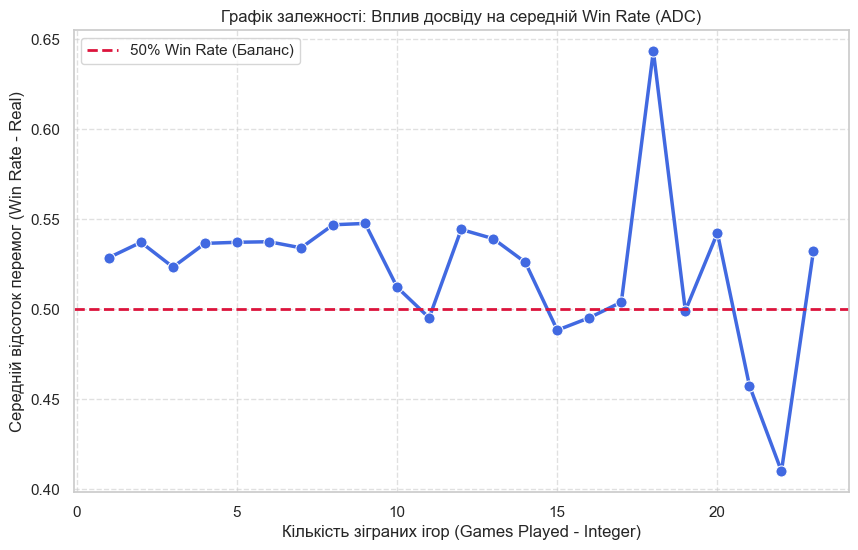

In [9]:
# Відфільтруємо нульові аномалії (беремо тільки тих гравців, хто зіграв від 1 до 40 ігор)
df_filtered = df[(df['blueADCGP'] > 0) & (df['blueADCGP'] <= 40)]

# Рахуємо середній вінрейт для кожної кількості зіграних ігор
trend_data = df_filtered.groupby('blueADCGP')['blueADCWR'].mean().reset_index()

plt.figure(figsize=(10, 6))

# Будуємо чистий лінійний графік з маркерами
sns.lineplot(data=trend_data, x='blueADCGP', y='blueADCWR', marker='o', color='royalblue', linewidth=2.5, markersize=8)

# Додаємо лінію балансу (50% вінрейту)
plt.axhline(0.5, color='crimson', linestyle='--', linewidth=2, label='50% Win Rate (Баланс)')

plt.title('Графік залежності: Вплив досвіду на середній Win Rate (ADC)')
plt.xlabel('Кількість зіграних ігор (Games Played - Integer)')
plt.ylabel('Середній відсоток перемог (Win Rate - Real)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4: Гістограма розподілу атрибута на 5 діапазонів
Згідно з вимогами лабораторної роботи, наступний графік демонструє розподіл одного з числових атрибутів, розбитий рівно на 5 заданих діапазонів.

Для аналізу обрано показник KDA стрільця синьої команди (`blueADCKDA`). Щоб графік був репрезентативним, з вибірки було попередньо виключено екстремальні математичні викиди (аномальні ігри з KDA > 15), які спотворювали масштаб осей. 

Очищена гістограма дозволяє наочно оцінити щільність розподілу результативності гравців:
* Чітко видно центральну тенденцію: абсолютна більшість стрільців закінчують гру з показником KDA у діапазоні від 0 до 6 (перші два кошики).
* Високий KDA (більше 9) зустрічається значно рідше, що підтверджує високу складність виживання на цій позиції.

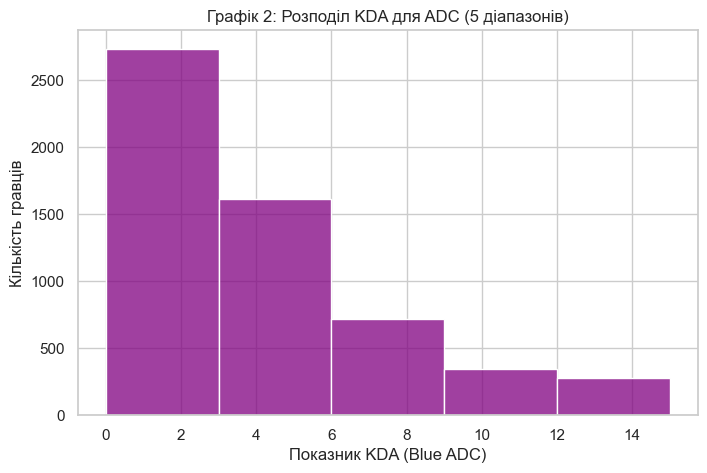

In [11]:
plt.figure(figsize=(8, 5))

# Відкидаємо аномалії: беремо для графіка тільки тих ADC, у кого KDA <= 15
realistic_kda = df[df['blueADCKDA'] <= 15]['blueADCKDA']

# Будуємо гістограму на 5 діапазонів для очищених даних
sns.histplot(realistic_kda, bins=5, color='purple', kde=False)

plt.title('Графік 2: Розподіл KDA для ADC (5 діапазонів)')
plt.xlabel('Показник KDA (Blue ADC)')
plt.ylabel('Кількість гравців')
plt.show()

### 5: Багатовимірні візуалізації
Згідно з вимогами лабораторної роботи, наступні графіки побудовані з використанням підходів до ефективної візуалізації 
багатовимірних даних (на основі прикладів зі статті на Medium). 

Щоб показати більше ніж дві змінні на плоскому екрані,я використала додаткові візуальні канали: колір та розмір точок .

**Графік 3: Порівняння лісників**
Для аналізу багатовимірних даних я побудовала графік, який порівнює результативність лісників обох команд. 

**Що доводить цей графік:**
 Пунктирна лінія розділяє графік навпіл. Як і очікувалося, у зоні "домінації синього лісника" (нижче лінії) візуально переважає концентрація перемог (синіх маркерів). 
Графік візуалізує важливий феномен — наявність червоних точок (поразок) глибоко в правій нижній зоні. Це матчі, де синій лісник мав колосальну перевагу за KDA (наприклад, 10 проти 2), але його команда все одно програла.

Отже візуалізація математично доводить, що метрика KDA є неповною. Високий показник вбивств на позиції лісника не конвертується у 100% вінрейт, можна вигравати всі бійки, і бути найкращим лісником але це тобі не допоможе якщо ти граєш з гравцями які вмирають по 20 разів на хвилину.

**Графік 4: Топографічний Pairplot (Аналіз синергії верхньої частини карти)**

Для вирішення проблеми перенасичення точок (overplotting) було використано метод двовимірної оцінки щільності (2D KDE). Графік працює як топографічна карта, де кільця показують місця найбільшої концентрації гравців.

**Що доводить цей графік:**
 На всіх трьох гістограмах щільності (Top, Jungle, Mid) ми бачимо чітку закономірність: синя крива (переможні матчі) має помітно ширший та вищий "хвіст" з правого боку порівняно з червоною (поразки). Це математично підтверджує, що гравці команди-переможця стабільно досягають вищих значень KDA, тоді як статистика переможених жорстко концентрується біля низьких значень (піки червоних кривих зліва).

Щодо контурних графіків то на всіх парних перетинах (наприклад, Jungle vs Mid) спостерігається ідентичний патерн: "ядро" червоних кілець (центр скупчення поразок) щільно притиснуте до лівого нижнього кута (KDA обох гравців близько 2-3). 
   Натомість ядро синіх кілець (центр перемог) помітно зміщене вгору та вправо (KDA обох гравців у зоні 4-6). Більше того, сині контури розтягуються значно далі по діагоналі. 

Отже графік візуально доводить макро-синергію ролей у League of Legends. Для перемоги команди недостатньо, щоб добре зіграла лише одна лінія. Контури показують, що високий вінрейт досягається тоді, коли показники KDA Топера, Лісника та Мідлейнера зростають одночасно.

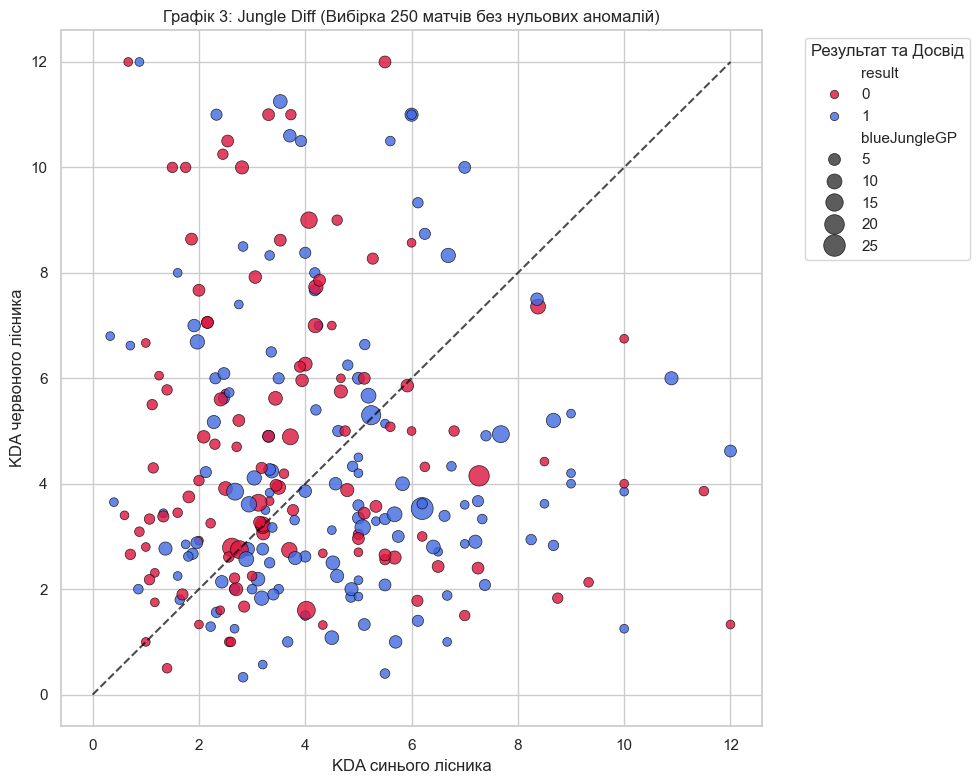

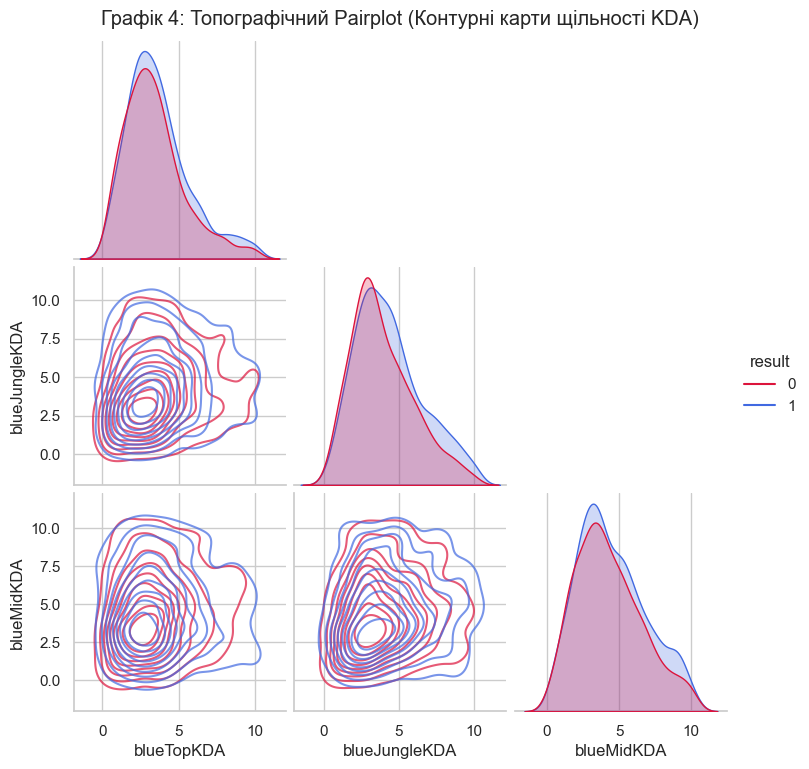

In [20]:
#Графік 3
plt.figure(figsize=(10, 8))

# Відкидаємо нулі та аномальні викиди
df_clean = df[(df['blueJungleKDA'] > 0) & (df['blueJungleKDA'] <= 12) & 
              (df['redJungleKDA'] > 0) & (df['redJungleKDA'] <= 12)]

#  беремо випадкові 250 матчів, щоб прибрати кашу
df_sample = df_clean.sample(n=250, random_state=42)

#  Будуємо графік
sns.scatterplot(
    data=df_sample, 
    x='blueJungleKDA', 
    y='redJungleKDA', 
    hue='result', 
    size='blueJungleGP', 
    sizes=(40, 250), # Бульбашки стали більшими
    palette=['crimson', 'royalblue'], 
    alpha=0.8,
    edgecolor='black' # Чорний контур для кожної точки (дуже гарно виглядає(стільно))
)

# Діагональна лінія рівності
plt.plot([0, 12], [0, 12], color='black', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title('Графік 3: Jungle Diff (Вибірка 250 матчів без нульових аномалій)')
plt.xlabel('KDA синього лісника')
plt.ylabel('KDA червоного лісника')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Результат та Досвід')
plt.tight_layout()
plt.show()

# Графік 4
metrics = ['blueTopKDA', 'blueJungleKDA', 'blueMidKDA']

# 1. Відрізаємо нулі та жорсткі викиди (KDA більше 10)
clean_pair_df = df[(df['blueTopKDA'] > 0) & (df['blueTopKDA'] <= 10) & 
                   (df['blueJungleKDA'] > 0) & (df['blueJungleKDA'] <= 10) & 
                   (df['blueMidKDA'] > 0) & (df['blueMidKDA'] <= 10)]

# 2. Будуємо Pairplot з контурними лініями замість крапок
sns.pairplot(
    clean_pair_df[metrics + ['result']], 
    hue='result', 
    palette=['crimson', 'royalblue'], 
    corner=True,
    kind='kde', # Двовимірна оцінка щільності (Kernel Density Estimation)
    plot_kws={'alpha': 0.7}
)

plt.suptitle('Графік 4: Топографічний Pairplot (Контурні карти щільності KDA)', y=1.02)
plt.show()

### 6: Комплексний огляд додаткових ігрових метрик (Subplots)
Для комплексного огляду створено фігуру з трьох різних типів візуалізацій (Barplot, Boxplot, KDE Plot). Для чистоти візуалізації графіків 6 та 7 дані було попередньо очищено від екстремальних викидів (KDA > 15-20).


* П'ятий графік у нас **Barplot (Стовпчикова діаграма)**, його використовують для відображення категоріальних даних. Показує загальну кількість або частоту подій (у нашому випадку — скільки матчів завершилися перемогою, а скільки поразкою).
* Шостий графік у нас**Boxplot (Діаграма розмаху)**,це потужний статистичний інструмент для оцінки розподілу. Сама "коробка" містить 50% усіх типових значень (від 25-го до 75-го перцентиля), лінія всередині — це медіана (середина даних), а "вуса" показують нормальний розмах. Усе, що за вусами (окремі крапки) — це математичні аномалії (викиди).
* Сьомий графік у нас **KDE Plot (Оцінка щільності ядра):** Це згладжена, неперервна альтернатива класичній гістограмі. Графік показує ймовірність або щільність концентрації даних. Чим вища і гостріша "гора", тим більше гравців мають саме такий показник KDA.

Висновок:
1. **Графік 5 (Баланс класів):** Barplot демонструє, що датасет є ідеально збалансованим. Кількість перемог та поразок синьої команди майже однакова, що робить наші подальші порівняння статистично валідними.
2. **Графік 6 (Вплив ворога):** Boxplot показує, що коли синя команда програє (0), медіана KDA ворожого стрільця (зелена коробка) значно вища. Ворожі керрі виживають частіше і мають довший "хвіст" викидів.
3. **Графік 7 (Розподіл результативності):** Графік щільності (KDE) замінив лінійний графік для уникнення візуального шуму. Він чітко доводить зсув парадигми: червона "гора" (поразки) має гострий пік біля KDA 1-2, тоді як синя гора (перемоги) є більш пологою і розтягнутою вправо. Це означає, що перемога гарантує стрільцю значно ширше вікно для набору високої статистики.

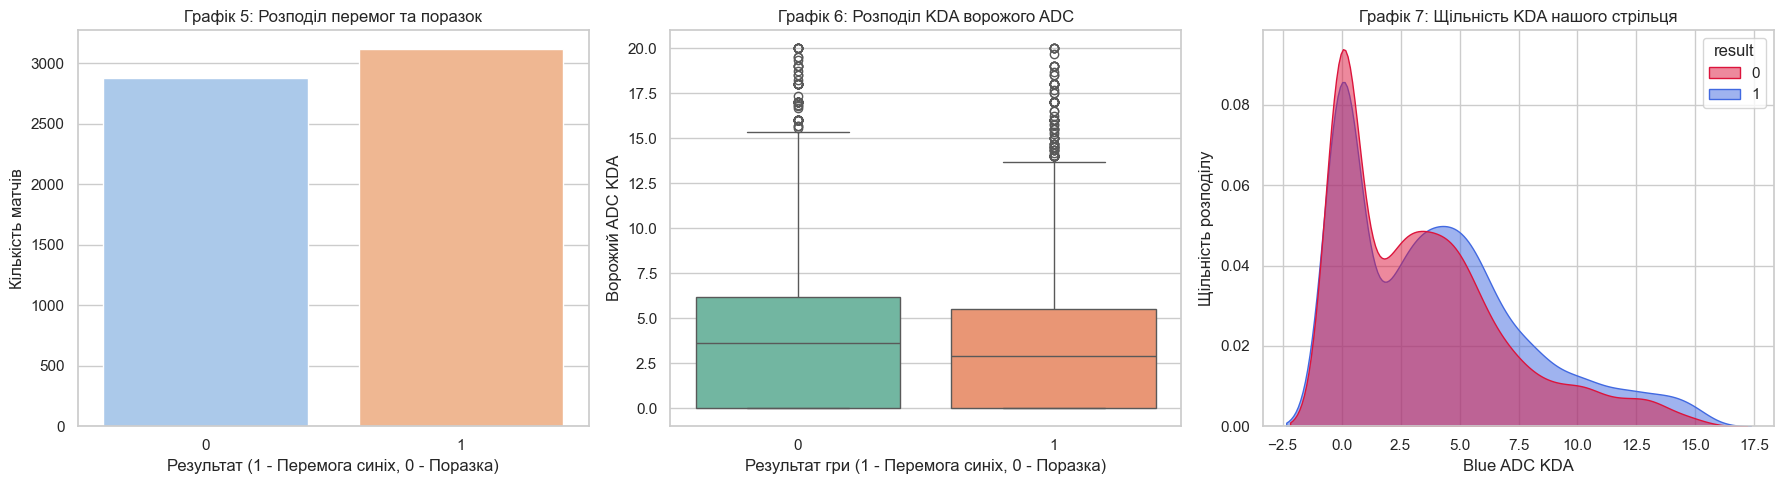

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 5: Barplot (Категоріальний) - Розподіл результатів матчів
sns.countplot(data=df, x='result', hue='result', legend=False, ax=axes[0], palette='pastel')
axes[0].set_title('Графік 5: Розподіл перемог та поразок')
axes[0].set_xlabel('Результат (1 - Перемога синіх, 0 - Поразка)')
axes[0].set_ylabel('Кількість матчів')

# Графік 6: Boxplot (Розподіл з викидами) - Фільтруємо аномалії > 20 для краси
clean_red_adc = df[df['redAdcKDA'] <= 20]
sns.boxplot(data=clean_red_adc, x='result', y='redAdcKDA', hue='result', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('Графік 6: Розподіл KDA ворожого ADC')
axes[1].set_xlabel('Результат гри (1 - Перемога синіх, 0 - Поразка)')
axes[1].set_ylabel('Ворожий ADC KDA')

# Графік 7: KDE Plot замість кривого Lineplot
clean_blue_adc = df[df['blueADCKDA'] <= 15]
sns.kdeplot(data=clean_blue_adc, x='blueADCKDA', hue='result', fill=True, ax=axes[2], palette=['crimson', 'royalblue'], alpha=0.5)
axes[2].set_title('Графік 7: Щільність KDA нашого стрільця')
axes[2].set_xlabel('Blue ADC KDA')
axes[2].set_ylabel('Щільність розподілу')

plt.tight_layout()
plt.show()